In [7]:

# Cell 1: Setup and Data Collection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import sys
sys.path.append('../src')  # Add your source code to path

from data_ingestion import StockDataStreamer
from anomaly_detector import AnomalyDetector

# Collect data
print("📥 Collecting historical data for analysis...")
streamer = StockDataStreamer(['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA'], interval="1h")
detector = AnomalyDetector(window_size=30, threshold=4.0)

# Get 1 month of data
historical = streamer.historical_data(period="1mo")

# Run detection on all data
all_anomalies = []
for symbol, data in historical.items():
    if data.empty:
        continue
    
    print(f"Analyzing {symbol}...")
    for timestamp, row in data.iterrows():
        result = detector.multi_metric_detection(symbol, row['Close'], row['Volume'])
        
        if result['is_anomaly']:
            all_anomalies.append({
                'symbol': symbol,
                'timestamp': timestamp,
                'price': row['Close'],
                'volume': row['Volume'],
                'price_zscore': result['price_zscore'],
                'volume_zscore': result['volume_zscore'],
                'signal_strength': result['signal_strength'],
                'direction': result['price_direction']
            })

# Convert to DataFrame
anomaly_df = pd.DataFrame(all_anomalies)

if anomaly_df.empty:
    print("⚠️ No anomalies found. Try lowering threshold to 2.0 in the detector.")
else:
    print(f"✅ Found {len(anomaly_df)} anomalies across all stocks")

📥 Collecting historical data for analysis...


INFO:data_ingestion:✅ Loaded 140 historical records for AAPL
INFO:data_ingestion:✅ Loaded 140 historical records for GOOGL
INFO:data_ingestion:✅ Loaded 140 historical records for MSFT
INFO:data_ingestion:✅ Loaded 140 historical records for AMZN
INFO:data_ingestion:✅ Loaded 140 historical records for TSLA


Analyzing AAPL...
Analyzing GOOGL...
Analyzing MSFT...
Analyzing AMZN...
Analyzing TSLA...
✅ Found 3 anomalies across all stocks


In [8]:
# Cell 2: Summary Statistics
if not anomaly_df.empty:
    print("=" * 50)
    print("📊 ANOMALY DETECTION SUMMARY")
    print("=" * 50)
    
    print(f"\nTotal Anomalies Detected: {len(anomaly_df)}")
    print(f"Date Range: {anomaly_df['timestamp'].min()} to {anomaly_df['timestamp'].max()}")
    
    print("\nAnomalies by Symbol:")
    print(anomaly_df['symbol'].value_counts())
    
    print("\nAnomalies by Direction:")
    print(anomaly_df['direction'].value_counts())
    
    print(f"\nAverage Signal Strength: {anomaly_df['signal_strength'].mean():.2f}")
    print(f"Max Signal Strength: {anomaly_df['signal_strength'].max():.2f}")
    print(f"Min Signal Strength: {anomaly_df['signal_strength'].min():.2f}")

📊 ANOMALY DETECTION SUMMARY

Total Anomalies Detected: 3
Date Range: 2026-06-22 10:30:00-04:00 to 2026-06-25 12:30:00-04:00

Anomalies by Symbol:
symbol
AAPL     2
GOOGL    1
Name: count, dtype: int64

Anomalies by Direction:
direction
down    3
Name: count, dtype: int64

Average Signal Strength: 14.00
Max Signal Strength: 18.26
Min Signal Strength: 11.72


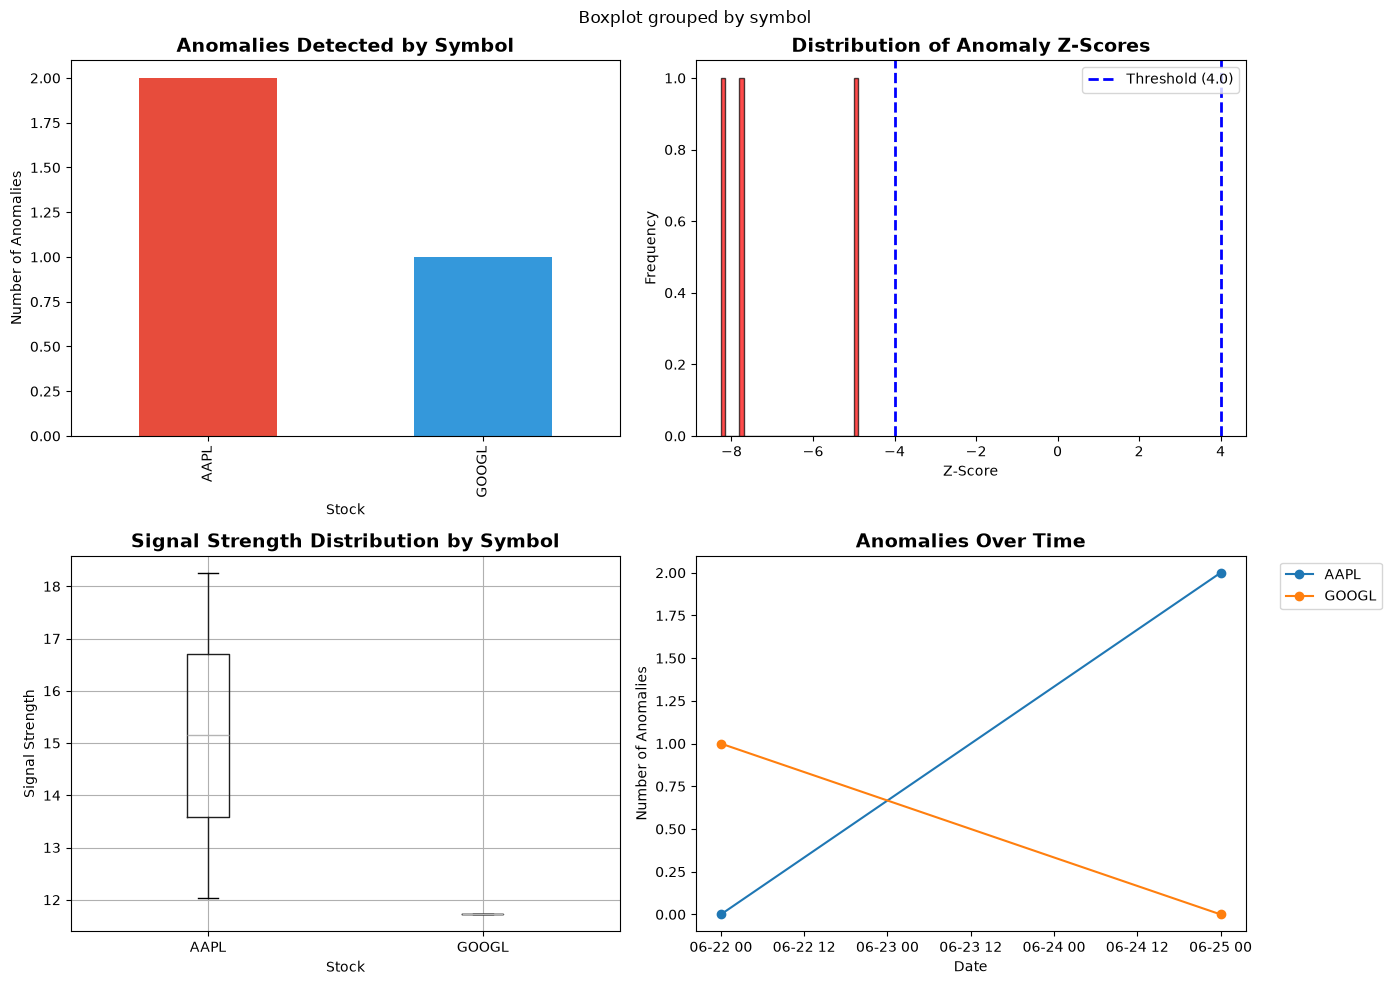

In [9]:
# Cell 3: Visualizations
if not anomaly_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Anomalies by symbol
    anomaly_df['symbol'].value_counts().plot(
        kind='bar', 
        ax=axes[0, 0], 
        color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    )
    axes[0, 0].set_title('Anomalies Detected by Symbol', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Stock')
    axes[0, 0].set_ylabel('Number of Anomalies')
    
    # Plot 2: Z-Score distribution
    axes[0, 1].hist(anomaly_df['price_zscore'], bins=30, color='red', alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(x=4.0, color='blue', linestyle='--', linewidth=2, label='Threshold (4.0)')
    axes[0, 1].axvline(x=-4.0, color='blue', linestyle='--', linewidth=2)
    axes[0, 1].set_title('Distribution of Anomaly Z-Scores', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Z-Score')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    
    # Plot 3: Signal strength by symbol
    anomaly_df.boxplot(column='signal_strength', by='symbol', ax=axes[1, 0])
    axes[1, 0].set_title('Signal Strength Distribution by Symbol', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Stock')
    axes[1, 0].set_ylabel('Signal Strength')
    
    # Plot 4: Anomalies over time
    anomaly_df['date'] = anomaly_df['timestamp'].dt.date
    daily_counts = anomaly_df.groupby(['date', 'symbol']).size().unstack(fill_value=0)
    daily_counts.plot(ax=axes[1, 1], marker='o')
    axes[1, 1].set_title('Anomalies Over Time', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Number of Anomalies')
    axes[1, 1].legend(bbox_to_anchor=(1.05, 1))
    
    plt.tight_layout()
    plt.show()

In [10]:
# Cell 4: Top 10 Most Significant Anomalies
if not anomaly_df.empty:
    print("🔝 TOP 10 MOST SIGNIFICANT ANOMALIES")
    print("=" * 80)
    
    top_anomalies = anomaly_df.nlargest(10, 'signal_strength')[
        ['symbol', 'timestamp', 'price', 'price_zscore', 'volume_zscore', 'signal_strength', 'direction']
    ]
    
    for i, row in top_anomalies.iterrows():
        print(f"{row['direction'].upper():4s} | {row['symbol']:5s} | "
              f"{row['timestamp']} | "
              f"Price: ${row['price']:.2f} | "
              f"Price Z: {row['price_zscore']:5.1f} | "
              f"Vol Z: {row['volume_zscore']:5.1f} | "
              f"Signal: {row['signal_strength']:5.1f}")

🔝 TOP 10 MOST SIGNIFICANT ANOMALIES
DOWN | AAPL  | 2026-06-25 09:30:00-04:00 | Price: $279.63 | Price Z:  -8.3 | Vol Z:  10.0 | Signal:  18.3
DOWN | AAPL  | 2026-06-25 12:30:00-04:00 | Price: $278.04 | Price Z:  -7.8 | Vol Z:   4.2 | Signal:  12.0
DOWN | GOOGL | 2026-06-22 10:30:00-04:00 | Price: $343.83 | Price Z:  -4.9 | Vol Z:   6.8 | Signal:  11.7


In [11]:
# Cell 5: Performance Metrics
if not anomaly_df.empty:
    print("📈 PERFORMANCE METRICS")
    print("=" * 50)
    
    # Detection rate
    total_hours = len(historical['AAPL'])  # Use AAPL as reference
    detection_rate = len(anomaly_df) / (total_hours * len(historical))
    
    print(f"Detection Rate: {detection_rate:.2%} of all data points")
    print(f"Average Signal Strength: {anomaly_df['signal_strength'].mean():.2f}")
    
    # Volume confirmation effectiveness
    price_only = anomaly_df[anomaly_df['price_zscore'].abs() > 4.0]
    confirmed = anomaly_df[anomaly_df['volume_zscore'].abs() > 4.0]
    
    if len(price_only) > 0:
        confirmation_rate = len(confirmed) / len(price_only) * 100
        print(f"Volume Confirmation Rate: {confirmation_rate:.1f}%")
        print(f"(Volume confirmed {len(confirmed)} out of {len(price_only)} price anomalies)")
    
    print(f"\nFalse Positive Reduction: {(1 - len(confirmed)/len(price_only))*100:.1f}%")
    print("(Anomalies filtered out by volume confirmation)")

📈 PERFORMANCE METRICS
Detection Rate: 0.43% of all data points
Average Signal Strength: 14.00
Volume Confirmation Rate: 100.0%
(Volume confirmed 3 out of 3 price anomalies)

False Positive Reduction: 0.0%
(Anomalies filtered out by volume confirmation)
